## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

Name: Andy Liu

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

alcohol = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alcohol.drop(columns=['total_litres_of_pure_alcohol'], inplace=True)

alcohol = alcohol.melt(id_vars=['country'],
                       var_name='drink',
                       value_name='servings')
alcohol.info()
alcohol

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   country   579 non-null    object
 1   drink     579 non-null    object
 2   servings  579 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 13.7+ KB


,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

Text(0.5, 0.98, 'Top 10 Countries that Drink the Most Spirits')

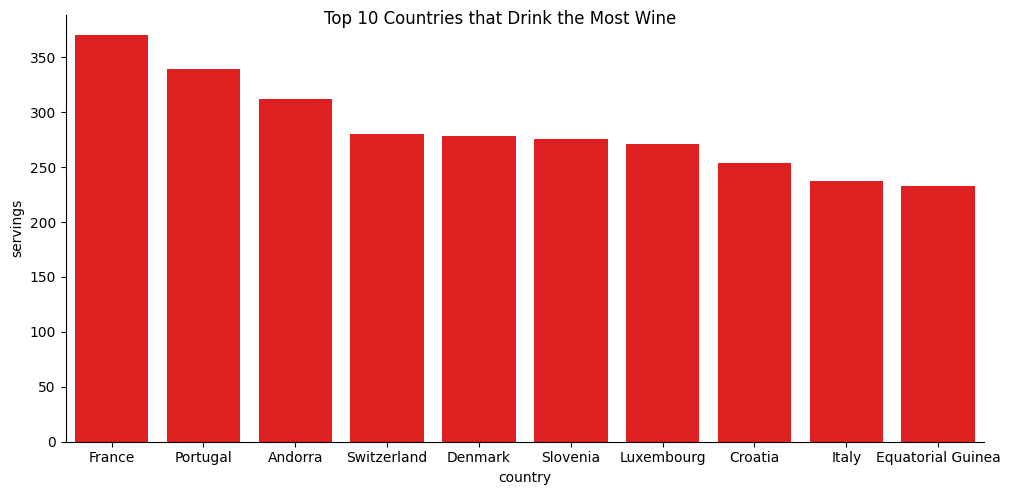

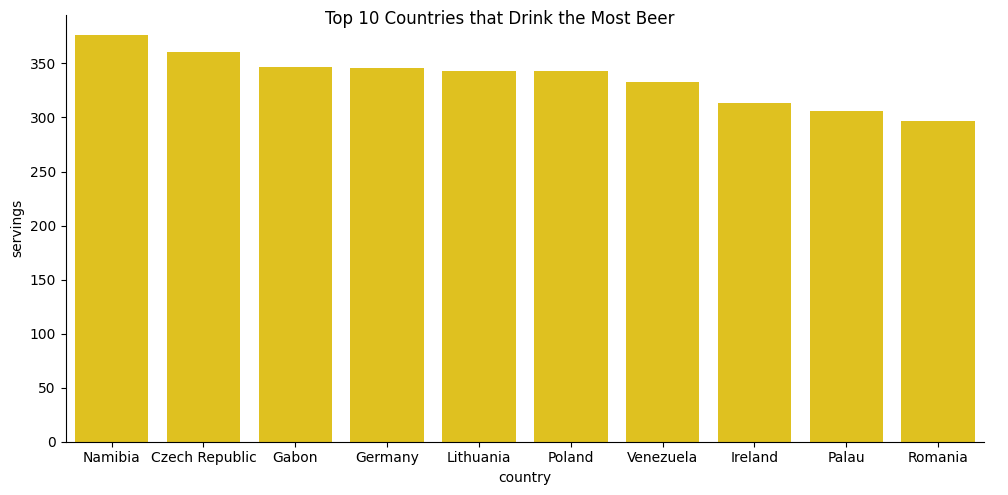

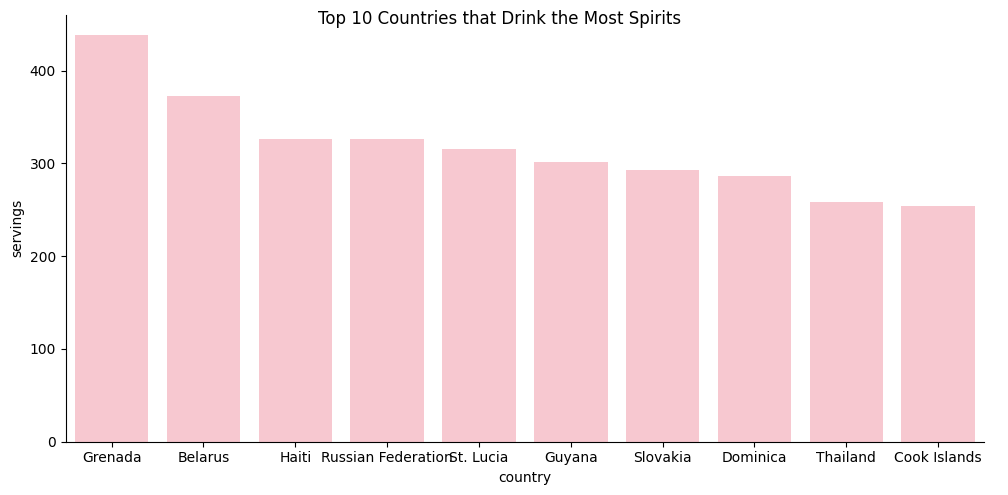

In [ ]:
alcohol['drink'] = alcohol['drink'].str.replace('_servings', '')
alcohol = alcohol.sort_values(['drink', 'servings'], ascending=[False, False])
alcohol

wine = sns.catplot(data=alcohol[alcohol['drink'] == 'wine'].head(10),
                   x='country',
                   y='servings',
                   kind='bar',
                   aspect=2,
                   color='red')
wine.fig.suptitle("Top 10 Countries that Drink the Most Wine")

beer = sns.catplot(data=alcohol[alcohol['drink'] == 'beer'].head(10),
                   x='country',
                   y='servings',
                   kind='bar',
                   aspect=2,
                   color='gold')
beer.fig.suptitle("Top 10 Countries that Drink the Most Beer")

spirit = sns.catplot(data=alcohol[alcohol['drink'] == 'spirit'].head(10),
                   x='country',
                   y='servings',
                   kind='bar',
                   aspect=2,
                   color='pink')
spirit.fig.suptitle("Top 10 Countries that Drink the Most Spirits")

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [ ]:
alcohol_wide = pd.pivot_table(alcohol, values='servings', index='country', columns='drink')
alcohol_wide = alcohol_wide.astype(int)
alcohol_wide


drink,beer,spirit,wine
country,,,
Afghanistan,0,0,0
Albania,89,132,54
Algeria,25,0,14
Andorra,245,138,312
Angola,217,57,45
...,...,...,...
Venezuela,333,100,3
Vietnam,111,2,1
Yemen,6,0,0
